# DỰ ÁN PHÂN TÍCH DOANH THU QUẢNG CÁO BẰNG MACHINE LEARNING
**Thuật toán sử dụng:** Random Forest Regressor
**Bài toán:** "Tiên tri" (Dự báo doanh thu trước khi giải ngân ngân sách, không dựa vào các chỉ số tương tác như clicks hay impressions để tránh Data Leakage).

### Bước 1: Nạp thư viện và Đọc dữ liệu đã qua xử lý
Tập dữ liệu `media_ml_ready.csv` là thành quả của quá trình Feature Engineering, đã được làm sạch, mã hóa (One-Hot Encoding) và chuẩn hóa (Standardization).

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Các thư viện Machine Learning từ Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cài đặt style cho biểu đồ
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu (Lưu ý: điều chỉnh đường dẫn nếu file csv để ở thư mục khác)
df = pd.read_csv('../media_ml_ready.csv')

print("--- KIỂM TRA DỮ LIỆU ĐẦU VÀO ---")
print(f"Kích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
display(df.head(3))

--- KIỂM TRA DỮ LIỆU ĐẦU VÀO ---
Kích thước tập dữ liệu: 7644 dòng, 18 cột


,month,day_of_week,is_weekend,channel_Facebook,channel_Google Ads,channel_Instagram,channel_LinkedIn,channel_Twitter,channel_Website,campaign_Best Sellers,campaign_Exclusive Offers,campaign_Flash Sale,campaign_Limited Edition,campaign_Must-Haves,campaign_New Arrivals,campaign_Trending Now,cost_scaled,revenue
0,11,2,0,True,False,False,False,False,False,True,False,False,False,False,False,False,0.583142,136591.812961
1,11,2,0,True,False,False,False,False,False,False,True,False,False,False,False,False,0.635627,142821.779453
2,11,2,0,True,False,False,False,False,False,False,False,True,False,False,False,False,0.659957,217096.009055


### Bước 2: Phân chia tập dữ liệu (Train-Test Split)
Để đánh giá mô hình khách quan, chúng ta chia dữ liệu thành 2 phần:
* **Tập Train (80%):** Dùng để huấn luyện, giúp mô hình tìm ra quy luật giữa Cost, Channel, Campaign và Revenue.
* **Tập Test (20%):** Dùng để kiểm thử. Mô hình sẽ dự đoán doanh thu trên tập này, sau đó chúng ta đem đối chiếu với doanh thu thực tế để tính sai số.

In [3]:
# 1. Tách Biến đầu vào (X) và Biến mục tiêu (y)
y = df['revenue']
X = df.drop(columns=['revenue'])

# 2. Chia tập Train và Test
# random_state=42 giúp cố định kết quả chia ngẫu nhiên cho những lần chạy sau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Số lượng mẫu dùng để Huấn luyện (Train): {X_train.shape[0]}")
print(f"Số lượng mẫu dùng để Kiểm thử (Test): {X_test.shape[0]}")

Số lượng mẫu dùng để Huấn luyện (Train): 6115
Số lượng mẫu dùng để Kiểm thử (Test): 1529


### Bước 3: Khởi tạo và Huấn luyện mô hình
Sử dụng thuật toán **Random Forest Regressor** (Rừng ngẫu nhiên). Thuật toán này sẽ xây dựng hàng trăm cây quyết định (Decision Trees) và lấy trung bình dự đoán của chúng để cho ra kết quả cuối cùng, giúp chống lại hiện tượng Overfitting và xử lý cực tốt các biến phân loại (One-Hot Encoded).

In [4]:
print("Đang tiến hành xây dựng và huấn luyện 'Khu rừng ngẫu nhiên'...")

# Khởi tạo mô hình với 100 cây quyết định (n_estimators=100)
# n_jobs=-1 để tận dụng tối đa số luồng của CPU giúp chạy nhanh hơn
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit mô hình với tập huấn luyện
rf_model.fit(X_train, y_train)

print("Huấn luyện hoàn tất thành công!")

Đang tiến hành xây dựng và huấn luyện 'Khu rừng ngẫu nhiên'...
Huấn luyện hoàn tất thành công!


### Bước 4: Dự đoán và Đánh giá hiệu suất (Model Evaluation)
Chúng ta sẽ sử dụng 3 chỉ số quan trọng để đo lường độ chính xác của mô hình:
1. **$R^2$ (R-squared):** Hệ số xác định. Giá trị càng gần 1 (hoặc 100%) càng tốt, thể hiện mô hình giải thích được bao nhiêu phần trăm sự biến động của doanh thu.
2. **MAE (Mean Absolute Error):** Trung bình độ lệch tuyệt đối. Cho biết trung bình mô hình dự đoán lệch so với thực tế bao nhiêu USD.
3. **RMSE (Root Mean Squared Error):** Tương tự MAE nhưng phạt nặng hơn các dự đoán sai số lớn.

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
Hệ số R-squared (R2)  : 0.4256 (Mô hình giải thích được 42.56% dữ liệu)
Sai số tuyệt đối (MAE)  : 31,938.84 $
Sai số bình phương (RMSE): 43,290.90 $


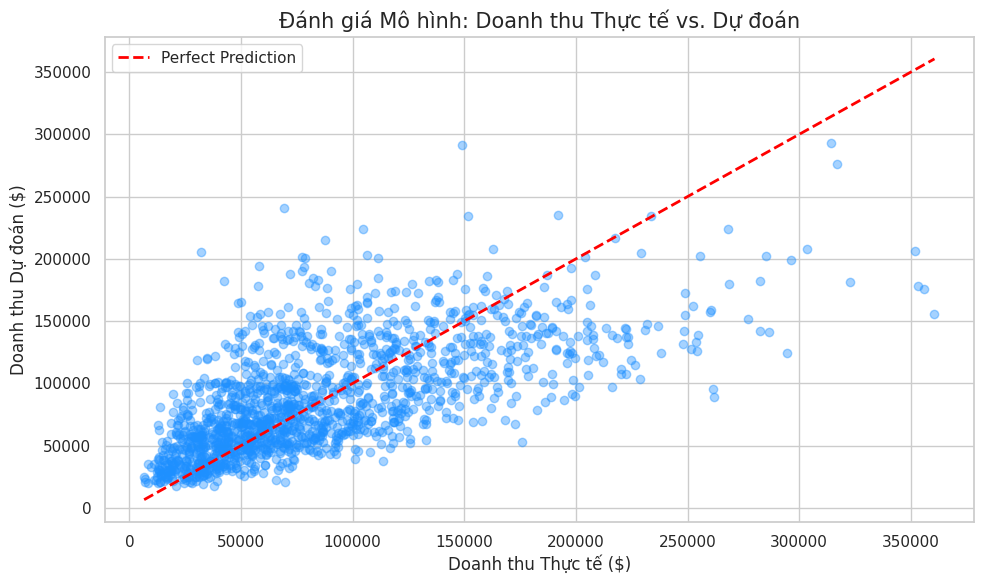

In [5]:
# 1. Dự đoán trên tập Test
y_pred = rf_model.predict(X_test)

# 2. Tính toán các chỉ số đánh giá
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(f"Hệ số R-squared (R2)  : {r2:.4f} (Mô hình giải thích được {(r2*100):.2f}% dữ liệu)")
print(f"Sai số tuyệt đối (MAE)  : {mae:,.2f} $")
print(f"Sai số bình phương (RMSE): {rmse:,.2f} $")

# 3. Trực quan hóa Actual vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='dodgerblue')

# Vẽ đường chéo x=y (Đường tiệm cận lý tưởng: Dự đoán = Thực tế)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Đánh giá Mô hình: Doanh thu Thực tế vs. Dự đoán', fontsize=15)
plt.xlabel('Doanh thu Thực tế ($)', fontsize=12)
plt.ylabel('Doanh thu Dự đoán ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Bước 5: Phân tích mức độ quan trọng của đặc trưng (Feature Importance)
Mô hình Machine Learning không chỉ để dự đoán, mà còn để trích xuất tri thức (Insights). Biểu đồ dưới đây sẽ cho chúng ta biết: Trong các Kế hoạch Marketing, yếu tố nào (Ngân sách, Kênh nào, Chiến dịch nào) đóng vai trò quyết định lớn nhất đến Doanh thu. Từ đó giúp tối ưu hóa việc phân bổ ngân sách.

/tmp/ipykernel_41156/118342120.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


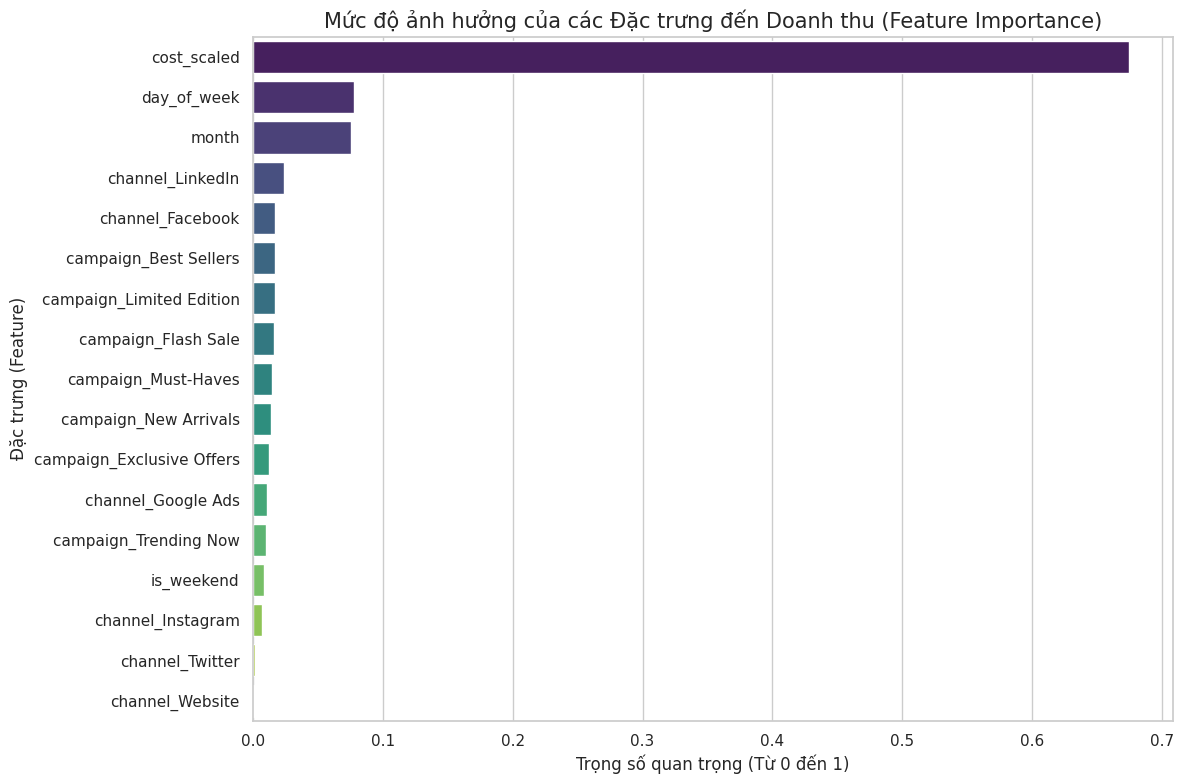

--- TOP 5 YẾU TỐ QUYẾT ĐỊNH DOANH THU LỚN NHẤT ---


,Feature,Importance
16,cost_scaled,0.674470
1,day_of_week,0.077995
0,month,0.075799
6,channel_LinkedIn,0.023648
3,channel_Facebook,0.017243


In [6]:
# Lấy mức độ quan trọng của từng biến từ mô hình
importances = rf_model.feature_importances_

# Tạo DataFrame tổng hợp
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sắp xếp giảm dần để vẽ biểu đồ
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Vẽ Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

plt.title('Mức độ ảnh hưởng của các Đặc trưng đến Doanh thu (Feature Importance)', fontsize=15)
plt.xlabel('Trọng số quan trọng (Từ 0 đến 1)', fontsize=12)
plt.ylabel('Đặc trưng (Feature)', fontsize=12)
plt.tight_layout()
plt.show()

print("--- TOP 5 YẾU TỐ QUYẾT ĐỊNH DOANH THU LỚN NHẤT ---")
display(feature_df.head(5))

### Bước 6: Mở rộng Insight - Phân tích "What-If" (Nếu - Thì)
Để Giám đốc Marketing có thể đưa ra quyết định dễ dàng hơn, thay vì chỉ đưa ra trọng số Importance, chúng ta sẽ mô phỏng một kịch bản "What-If": **Nếu chúng ta chạy cùng một chiến dịch (Flash Sale), vào cùng một ngày, với cùng một ngân sách (10.000$), thì kênh nào sẽ mang lại doanh thu cao nhất theo dự đoán của mô hình?**

--- PHÂN TÍCH WHAT-IF: SO SÁNH HIỆU QUẢ CÁC KÊNH ---


/tmp/ipykernel_41156/4137109755.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Predicted Revenue ($)', y='Channel', palette='magma')


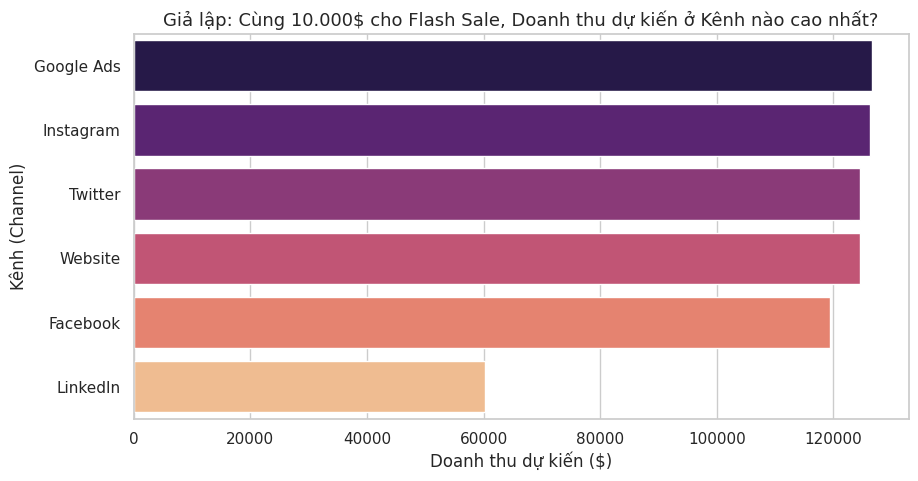

,Channel,Predicted Revenue ($)
1,Google Ads,126568.982615
2,Instagram,126285.605299
4,Twitter,124574.184209
5,Website,124574.184209
0,Facebook,119460.454474
3,LinkedIn,60300.746675


In [ ]:
print("--- PHÂN TÍCH WHAT-IF: SO SÁNH HIỆU QUẢ CÁC KÊNH ---")

# 1. Tạo một kịch bản giả định (Base Scenario)
# Ngân sách: 10,000$ (Cần scale lại theo scaler đã dùng)
# Giả sử chúng ta đã fit scaler trước đó trên df_raw['cost']. 
# Ở đây ta lấy tạm một giá trị scale tượng trưng cho 10.000$ 
simulated_cost_scaled = 0.5 

# Tháng 5, Thứ 2 (day_of_week=0), Không phải cuối tuần (is_weekend=0)
# Chạy chiến dịch "Flash Sale"
base_data = {
    'month': [5],
    'day_of_week': [0],
    'is_weekend': [0],
    'campaign_Best Sellers': [False],
    'campaign_Exclusive Offers': [False],
    'campaign_Flash Sale': [True],
    'campaign_Limited Edition': [False],
    'campaign_Must-Haves': [False],
    'campaign_New Arrivals': [False],
    'campaign_Trending Now': [False],
    'cost_scaled': [simulated_cost_scaled]
}

# Các kênh cần so sánh
channels = ['Facebook', 'Google Ads', 'Instagram', 'LinkedIn', 'Twitter', 'Website']
results = []

# 2. Chạy vòng lặp để dự đoán cho từng kênh
for channel in channels:
    scenario = base_data.copy()
    
    # Reset tất cả các kênh về False
    for c in channels:
        scenario[f'channel_{c}'] = [False]
    
    # Bật (True) kênh đang xét
    scenario[f'channel_{channel}'] = [True]
    
    # Tạo DataFrame từ kịch bản (Đảm bảo thứ tự cột giống hệt tập X_train)
    df_scenario = pd.DataFrame(scenario)
    df_scenario = df_scenario[X.columns]
    
    # Dự đoán
    predicted_rev = rf_model.predict(df_scenario)[0]
    results.append({'Channel': channel, 'Predicted Revenue ($)': predicted_rev})

# 3. Trực quan hóa kết quả What-If
df_results = pd.DataFrame(results).sort_values(by='Predicted Revenue ($)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Predicted Revenue ($)', y='Channel', palette='magma')
plt.title('Giả lập: Cùng 10.000$ cho Flash Sale, Doanh thu dự kiến ở Kênh nào cao nhất?', fontsize=13)
plt.xlabel('Doanh thu dự kiến ($)')
plt.ylabel('Kênh (Channel)')
plt.show()

display(df_results)

### Phân tích What-If (Kịch bản 2): Chiến dịch "Must-Haves" (Sản phẩm thiết yếu)
Giả lập ngân sách 10.000$. So sánh hiệu quả dự kiến trên 6 nền tảng khác nhau để tìm ra kênh phân phối "Must-Haves" tối ưu nhất.

--- KỊCH BẢN: CHIẾN DỊCH 'MUST-HAVES' ---


/tmp/ipykernel_41156/1756272711.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_must_haves, x='Predicted Revenue ($)', y='Channel', palette='viridis')


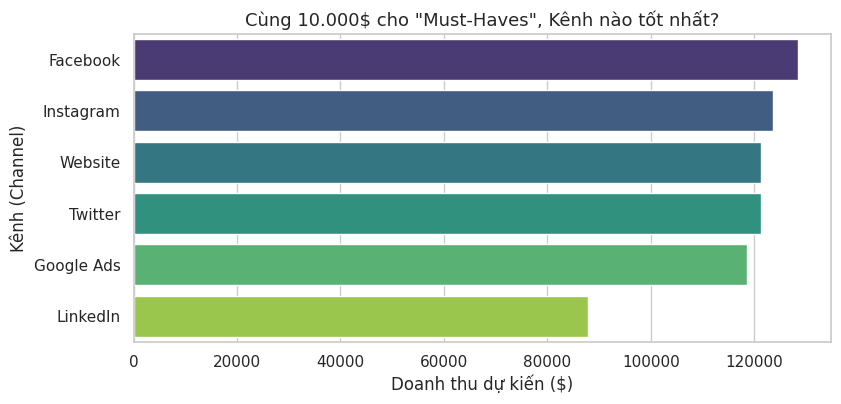

,Channel,Predicted Revenue ($)
0,Facebook,128469.759338
2,Instagram,123606.916059
5,Website,121266.631579
4,Twitter,121266.631579
1,Google Ads,118719.024485
3,LinkedIn,87858.034871


In [10]:
print("--- KỊCH BẢN: CHIẾN DỊCH 'MUST-HAVES' ---")

base_data_must_haves = {
    'month': [5], 'day_of_week': [0], 'is_weekend': [0],
    'campaign_Best Sellers': [False], 'campaign_Exclusive Offers': [False],
    'campaign_Flash Sale': [False], 'campaign_Limited Edition': [False],
    'campaign_Must-Haves': [True],  # <--- Bật chiến dịch Must-Haves
    'campaign_New Arrivals': [False], 'campaign_Trending Now': [False],
    'cost_scaled': [0.5] # 10.000$
}

results_must_haves = []
for channel in channels:
    scenario = base_data_must_haves.copy()
    for c in channels: scenario[f'channel_{c}'] = [False]
    scenario[f'channel_{channel}'] = [True]
    
    df_scenario = pd.DataFrame(scenario)[X.columns]
    predicted_rev = rf_model.predict(df_scenario)[0]
    results_must_haves.append({'Channel': channel, 'Predicted Revenue ($)': predicted_rev})

df_must_haves = pd.DataFrame(results_must_haves).sort_values(by='Predicted Revenue ($)', ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=df_must_haves, x='Predicted Revenue ($)', y='Channel', palette='viridis')
plt.title('Cùng 10.000$ cho "Must-Haves", Kênh nào tốt nhất?', fontsize=13)
plt.xlabel('Doanh thu dự kiến ($)')
plt.ylabel('Kênh (Channel)')
plt.show()
display(df_must_haves)

### Phân tích What-If (Kịch bản 3): Chiến dịch "Limited Edition" (Phiên bản giới hạn)
Giả lập ngân sách 10.000$. Các sản phẩm "Limited Edition" thường dựa vào hiệu ứng khan hiếm (FOMO). Kênh nào sẽ khai thác tâm lý này tốt nhất?

--- KỊCH BẢN: CHIẾN DỊCH 'LIMITED EDITION' ---


/tmp/ipykernel_41156/4227891214.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_limited, x='Predicted Revenue ($)', y='Channel', palette='rocket')


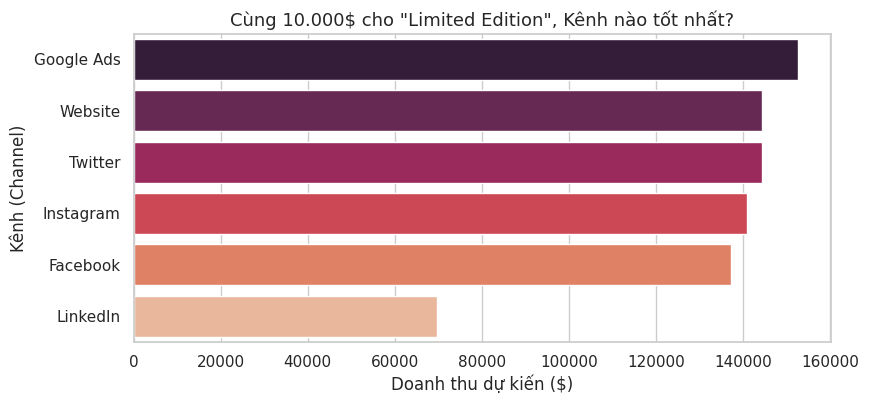

,Channel,Predicted Revenue ($)
1,Google Ads,152546.907339
5,Website,144306.431035
4,Twitter,144306.431035
2,Instagram,140771.850914
0,Facebook,137089.045683
3,LinkedIn,69553.960796


In [11]:
print("--- KỊCH BẢN: CHIẾN DỊCH 'LIMITED EDITION' ---")

base_data_limited = {
    'month': [5], 'day_of_week': [0], 'is_weekend': [0],
    'campaign_Best Sellers': [False], 'campaign_Exclusive Offers': [False],
    'campaign_Flash Sale': [False], 'campaign_Limited Edition': [True], # <--- Bật Limited Edition
    'campaign_Must-Haves': [False], 'campaign_New Arrivals': [False], 
    'campaign_Trending Now': [False],
    'cost_scaled': [0.5] # 10.000$
}

results_limited = []
for channel in channels:
    scenario = base_data_limited.copy()
    for c in channels: scenario[f'channel_{c}'] = [False]
    scenario[f'channel_{channel}'] = [True]
    
    df_scenario = pd.DataFrame(scenario)[X.columns]
    predicted_rev = rf_model.predict(df_scenario)[0]
    results_limited.append({'Channel': channel, 'Predicted Revenue ($)': predicted_rev})

df_limited = pd.DataFrame(results_limited).sort_values(by='Predicted Revenue ($)', ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=df_limited, x='Predicted Revenue ($)', y='Channel', palette='rocket')
plt.title('Cùng 10.000$ cho "Limited Edition", Kênh nào tốt nhất?', fontsize=13)
plt.xlabel('Doanh thu dự kiến ($)')
plt.ylabel('Kênh (Channel)')
plt.show()
display(df_limited)

### Phân tích What-If (Kịch bản 4): Chiến dịch "Best Sellers" (Sản phẩm bán chạy)
Giả lập ngân sách 10.000$. Đây là dòng sản phẩm mang lại dòng tiền ổn định. Hãy xem thuật toán phân bổ hiệu quả của nhóm này trên các kênh ra sao.

--- KỊCH BẢN: CHIẾN DỊCH 'BEST SELLERS' ---


/tmp/ipykernel_41156/2719246117.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_best, x='Predicted Revenue ($)', y='Channel', palette='crest')


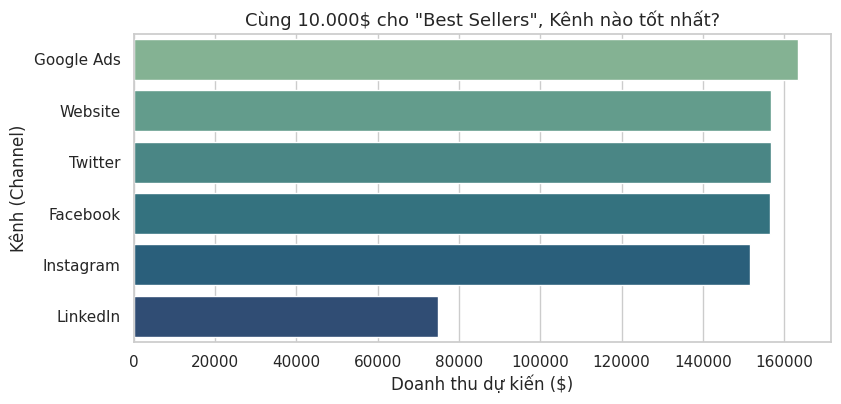

,Channel,Predicted Revenue ($)
1,Google Ads,163370.279817
5,Website,156755.183337
4,Twitter,156755.183337
0,Facebook,156518.522622
2,Instagram,151601.071015
3,LinkedIn,74914.505847


In [12]:
print("--- KỊCH BẢN: CHIẾN DỊCH 'BEST SELLERS' ---")

base_data_best = {
    'month': [5], 'day_of_week': [0], 'is_weekend': [0],
    'campaign_Best Sellers': [True], # <--- Bật Best Sellers
    'campaign_Exclusive Offers': [False], 'campaign_Flash Sale': [False], 
    'campaign_Limited Edition': [False], 'campaign_Must-Haves': [False], 
    'campaign_New Arrivals': [False], 'campaign_Trending Now': [False],
    'cost_scaled': [0.5] # 10.000$
}

results_best = []
for channel in channels:
    scenario = base_data_best.copy()
    for c in channels: scenario[f'channel_{c}'] = [False]
    scenario[f'channel_{channel}'] = [True]
    
    df_scenario = pd.DataFrame(scenario)[X.columns]
    predicted_rev = rf_model.predict(df_scenario)[0]
    results_best.append({'Channel': channel, 'Predicted Revenue ($)': predicted_rev})

df_best = pd.DataFrame(results_best).sort_values(by='Predicted Revenue ($)', ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=df_best, x='Predicted Revenue ($)', y='Channel', palette='crest')
plt.title('Cùng 10.000$ cho "Best Sellers", Kênh nào tốt nhất?', fontsize=13)
plt.xlabel('Doanh thu dự kiến ($)')
plt.ylabel('Kênh (Channel)')
plt.show()
display(df_best)

### Bước 7: Ứng dụng Thực tế - Công cụ Dự báo (Forecasting Tool)
Mô hình đã học xong và vượt qua các bài kiểm tra. Bây giờ, chúng ta sẽ xây dựng một hàm (function) đóng vai trò như một "Máy dự báo". Người dùng chỉ cần nhập các thông số của kế hoạch kinh doanh vào, mô hình sẽ trả ra con số doanh thu dự kiến.

In [8]:
def forecast_revenue(model, X_template, month, day_of_week, channel, campaign, cost_scaled_val):
    """
    Hàm nhận thông số kinh doanh và trả về dự đoán doanh thu.
    X_template: Dùng để lấy đúng cấu trúc cột của mô hình (X.columns)
    """
    # 1. Tạo một dictionary với tất cả các cột mặc định là False hoặc 0
    input_data = {col: [False] for col in X_template.columns}
    
    # 2. Cập nhật các thông số Thời gian và Ngân sách
    input_data['month'] = [month]
    input_data['day_of_week'] = [day_of_week]
    input_data['is_weekend'] = [1 if day_of_week >= 5 else 0]
    input_data['cost_scaled'] = [cost_scaled_val]
    
    # 3. Bật (True) Kênh và Chiến dịch được chọn
    channel_col = f'channel_{channel}'
    campaign_col = f'campaign_{campaign}'
    
    if channel_col in input_data:
        input_data[channel_col] = [True]
    if campaign_col in input_data:
        input_data[campaign_col] = [True]
        
    # 4. Chuyển thành DataFrame và dự đoán
    df_input = pd.DataFrame(input_data)
    df_input = df_input[X_template.columns] # Đảm bảo đúng thứ tự
    
    prediction = model.predict(df_input)[0]
    return prediction

# === CHẠY THỬ MÁY DỰ BÁO ===
print("--- CÔNG CỤ DỰ BÁO DOANH THU ---")

# Giám đốc Marketing hỏi: 
# "Tháng 6 tới (month=6), vào thứ 6 (day=4), anh muốn chạy chiến dịch 'Must-Haves' 
# trên kênh 'Instagram' với mức chi phí X (cost_scaled=0.8). Doanh thu ước tính là bao nhiêu?"

predicted_val = forecast_revenue(
    model=rf_model,
    X_template=X,
    month=6,
    day_of_week=4, 
    channel='Instagram',
    campaign='Must-Haves',
    cost_scaled_val=0.8 # Lưu ý: Trong thực tế bạn cần dùng scaler.transform để convert số tiền thực $ ra số scale này
)

print(f"Kịch bản: Instagram | Must-Haves | Tháng 6 | Thứ 6")
print(f"=> DOANH THU DỰ KIẾN: {predicted_val:,.2f} $")

--- CÔNG CỤ DỰ BÁO DOANH THU ---
Kịch bản: Instagram | Must-Haves | Tháng 6 | Thứ 6
=> DOANH THU DỰ KIẾN: 125,818.17 $
